# **TAS (Tele Assistance System) Stochastic Modelling**
NOTE: _[DASA CASE STUDY 1]_

## **Summary**

This notebook is focused on three main objectives:
1. summarizing the key aspects of the Tele Assistance System (TAS) architecture and its adaptive capabilities in the context of telehealth services for chronic patients.
2. Modelling the TAS architecture using appropriate design notations and tools to visualize its components and interactions.
3. Stochasticly Simulate the TAS behavior under different scenarios to evaluate its performance and adaptability with Queue Network (QN) models.

The results will be used to evaluate the Dimensional Analysis for Software Architecture (DASA) methodology, its software tool (PyDASA) and its effectiveness in modelling and Quality Scenarios (QS) trade-off in self-adaptive-systems (SAS).

---

## **Software Architecture**
- TAS (Tele Assistance System) operates in a dynamic environment where service quality, availability, and user needs frequently change.
- The TAS is further subdivided into Controller and Target System subsystem components.
- The Controller is responsible for managing the overall system behavior, while the Target System focuses on executing specific tasks related to patient care.
- The TAS target systems follows a Service-oriented architecture (SOA) pattern.
- The TAS Controller follows a MAPE-K (Monitor-Analyze-Plan-Execute-Knowledge) feedback loop for self-adaptation.
- Adaptations focus on maintaining **reliability**, **performance**, and **compliance** with patient care standards (5 specific scenarios).
- ActivFORMS provides the runtime framework for model-based adaptation using runtime models, simulations, and verified decision-making.

---

_**NOTE: MORE DETAILS ON THE ARCHITECTURE IN THE ANALYTICAL MODELLING NOTEBOOK!.**_

---

## **Target System Queue Network Model**

<svg viewBox="0 0 4650 2000" width="1400" height="650">
    <!-- SVG content -->
    <image href="assets/cs1/img/04A - Queue Network.svg" alt="queue-net-diagram" />
    <div align="center"><em>Image 1. TAS Queue Network Diagram.</em></div>
</svg>

## **Code**

_**SUMMARY:**_

This code is for the stochastic simulation of the Case Study (TAS) Queue Network Model and is structured as follows:
1. Analytical Queue Network (QN) model
2. Importing necessary libraries and modules.
3. Loading QN default configuration.
4. Simulating the QN analytically (Stochastic Process).
5. Plotting the QN with the obtained metrics.
6. Loading QN 'optimal' configuration.
7. Simulating the QN optimally (Stochastic Process).
8. Plotting the optimal QN with the obtained metrics.
9. Saving the results.
10. Comparing the simulation results (Default Vs. Optimal)
11. Visualizing the results.
12. Generating a summary report.

### **Necessary Imports**

In [1]:
# -*- coding: utf-8 -*-
# Native imports
import os
import re
import sys
import time
from typing import Union

# Third-party imports
import numpy as np
import pandas as pd

# import queue stochastic network + models packages
from src.model.analytical import calculate_net_metrics
# from src.simulation.network import QueueNode
# from src.simulation.network import job_generator, job
from src.simulation.network import simulate_network

# import plot functions + grahics
from src.view.plots import plot_queue_network
from src.view.plots import plot_net_comparison
from src.view.plots import plot_net_difference
from src.view.plots import plot_nodes_heatmap
from src.view.plots import plot_nodes_diffmap

### **Function Definitions**

In [2]:
# Simple formatter for console output

def fmt(val: Union[int, float, np.number]) -> Union[str, np.ndarray]:
    """Format a number to 4 decimal places for console output.

    Args:
        val (Union[int, float, np.number, np.ndarray]): The value to format.

    Returns:
        Union[str, np.ndarray]: The formatted value as a string or an array of strings.
    """
    if isinstance(val, (int, float, np.number)):
        if np.isnan(val) or np.isinf(val):
            return str(val)
        return f"{val:.4f}"
    elif isinstance(val, np.ndarray):
        return np.array([fmt(x) for x in val])
    return val

In [3]:
# Load configuration from a CSV file
def load(path: str, fname: str) -> pd.DataFrame:
    """Load configuration from a CSV file.

    Args:
        path (str): The directory path where the CSV file is located.
        fname (str): The name of the CSV file to load.

    Returns:
        pd.DataFrame: A DataFrame containing the configuration data.
            CSV format:
                - node: <node_id>
                - miu: <mean_service_time>
                - c: <service_channels>
                - K: <buffer_capacity | max_queue_length>
                - lambda0: <initial_arrival_rate>
                - L0: <initial_queue_length>
                - pm: <matrix_routing_probabilities>
    """
    # path = os.path.dirname(__file__)
    _file_path = os.path.join(path, fname)
    print(f"Loading configuration from: {_file_path}")
    df = pd.read_csv(_file_path)
    return df

In [4]:
# save dataframes in CSV files
def save(path: str, fname: str, data: pd.DataFrame) -> None:
    """Save a DataFrame to a CSV file.

    Args:
        path (str): The directory path where the CSV file will be saved.
        fname (str): The name of the CSV file to save.
        data (pd.DataFrame): The DataFrame containing the data to save.
    """
    # path = os.path.dirname(__file__)
    _file_path = os.path.join(path, fname)
    print(f"Saving data to: {_file_path}")
    data.to_csv(_file_path, index=False)

In [5]:
def config_stochastics_model(cfg_df: pd.DataFrame, verbose=False) -> tuple:
    """Configure the stochastic queue model based on the provided configuration DataFrame.

    Args:
        cfg_df (pd.DataFrame): configuration DataFrame
        verbose (bool, optional): If True, print detailed information. Defaults to False.

    Returns:
        tuple: A tuple containing the configured parameters and queue objects specifically:
            - mus (list): List of service rates.
            - lambda_zs (list): List of arrival rates.
            - servers (list): List of number of servers.
            - kaps (list): List of capacities.
            - P (np.ndarray): Routing probability matrix.
    """

    # extract parameters from the configuration DataFrame
    # and casting them to proper types
    nodes = cfg_df["node"].values.astype(int).tolist()
    names = cfg_df["name"].values.tolist()
    types = cfg_df["type"].values.tolist()
    mus = cfg_df["mu"].values.tolist()
    lambda_zs = cfg_df["lambda_z"].values.tolist()
    n_servers = cfg_df["c"].values.astype(int).tolist()
    kaps = cfg_df["K"].values.astype(float).tolist()

    # Convert K=0=nan to understandable infinite capacity -> None
    for i in range(len(kaps)):
        if np.isnan(kaps[i]):
            if verbose:
                _msg = f"Node {nodes[i]}: K is 'NaN', "
                _msg += "setting capacity to None (infinite)"
                print(_msg)
            kaps[i] = None
        else:
            kaps[i] = float(kaps[i])

    # Convert string representations of arrays to actual numpy arrays
    # and create routing matrix P
    prob = []
    for pm_str in cfg_df["P_routing"].values.tolist():
        routing_val = pm_str.strip("[]").split(",")
        routing_val = [float(val) for val in routing_val]
        prob.append(routing_val)
    P_routing = np.array((prob))

    # create analytical model tuple
    ans = (mus, lambda_zs, n_servers, kaps, P_routing)
    return ans

In [6]:
# path = os.path.dirname(__file__)\
PATH = os.getcwd()
print(f"Notebook path: {PATH}")

Notebook path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies


In [7]:
# Folder names
asset_folder = "assets"
config_folder = "config"
docs_folder = "docs"
img_folder = "img"
data_folder = "data"
report_folder = "reports"
results_folder = "results"
cs_folder = "cs1"

In [8]:
# setting case study configuration folder
file_path = os.path.join(PATH, data_folder, config_folder, cs_folder)
print(f"Configuration file path: {file_path}")

Configuration file path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\config\cs1


In [9]:
print("--- Config stochastic sampling settings ---")
n_reps = 3   # number of replications per experiment
print(f"Number of replications per experiment: {n_reps}")
n_exp = 1000  # number of experiments
print(f"Number of experiments: {n_exp}")
n_warmup = 100  # number of warm-up jobs
print(f"Number of warm-up jobs: {n_warmup}")

--- Config stochastic sampling settings ---
Number of replications per experiment: 3
Number of experiments: 1000
Number of warm-up jobs: 100


### **Queue Model**
#### **Stochastic Simulation**
##### **Base Configuration**

In [10]:
# Load configuration with mixed queue models
dflt_qn_cfg = load(file_path, "default_qn_model.csv")
print("Queue Network Configuration:")
dflt_qn_cfg.head()

Loading configuration from: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\config\cs1\default_qn_model.csv
Queue Network Configuration:


,node,name,type,mu,c,K,lambda_z,L_z,P_routing
0,1,TAS 1 (1)*,M/M/s/K,900,1,10,345,0,"[0.00,0.75,0.25,0.00,0.00,0.00,0.00,0.00,0.00,..."
1,2,TAS 2 (1)*,M/M/s/K,700,1,10,0,0,"[0.00,0.00,0.00,0.33,0.33,0.33,0.00,0.00,0.00,..."
2,3,TAS 3 (1)*,M/M/s/K,700,1,10,0,0,"[0.00,0.00,0.00,0.00,0.00,0.00,0.33,0.33,0.33,..."
3,4,MAS 1,M/M/s/K,180,1,10,0,0,"[0.00,0.00,0.00,0.12,0.00,0.00,0.00,0.00,0.00,..."
4,5,MAS 2,M/M/s/K,530,1,10,0,0,"[0.00,0.00,0.00,0.00,0.07,0.00,0.00,0.00,0.00,..."


In [11]:
print("--- Configuring default stochastic queue model ---")
dflt_stochastics_model = config_stochastics_model(dflt_qn_cfg, verbose=True)

--- Configuring default stochastic queue model ---


In [12]:
print("--- Executing default stochastic network simulation ---")
dflt_simul_nd_metrics = simulate_network(*dflt_stochastics_model,
                                         n_exp=n_exp,
                                         warm_exp=n_warmup,
                                         reps=n_reps,
                                         verbose=True)

--- Executing default stochastic network simulation ---
--- Running Replication 1/3 ---
--- Running Replication 2/3 ---
--- Running Replication 3/3 ---

=== Summary Statistics Across Replications ===
(13, 21)


In [13]:
print("--- Renaming default simulation network metrics ---")
src_df_cols = dflt_simul_nd_metrics.columns.tolist()
exp = r"_mean$"
mean_cols = [col for col in src_df_cols if re.search(exp, col)]
print(f"Mean column names: {mean_cols}")

tgt_df_cols = [col.replace("_mean", "") for col in mean_cols]
print(f"Target column names: {tgt_df_cols}")

dflt_simul_nd_metrics_mean = pd.DataFrame(dflt_simul_nd_metrics[mean_cols])
# rename colums
rename_dict = dict(zip(mean_cols, tgt_df_cols))
print(f"Rename dictionary: {rename_dict}")
dflt_simul_nd_metrics.rename(columns=rename_dict, inplace=True)

--- Renaming default simulation network metrics ---
Mean column names: ['lambda_mean', 'mu_mean', 'rho_mean', 'L_mean', 'Lq_mean', 'W_mean', 'Wq_mean', 'Jobs_Served_mean', 'Jobs_Blocked_mean', 'Blocking_Prob_mean']
Target column names: ['lambda', 'mu', 'rho', 'L', 'Lq', 'W', 'Wq', 'Jobs_Served', 'Jobs_Blocked', 'Blocking_Prob']
Rename dictionary: {'lambda_mean': 'lambda', 'mu_mean': 'mu', 'rho_mean': 'rho', 'L_mean': 'L', 'Lq_mean': 'Lq', 'W_mean': 'W', 'Wq_mean': 'Wq', 'Jobs_Served_mean': 'Jobs_Served', 'Jobs_Blocked_mean': 'Jobs_Blocked', 'Blocking_Prob_mean': 'Blocking_Prob'}


In [14]:
# then network metrics
print("--- Calculating default simulation network metrics ---")
dflt_simul_net_metrics = calculate_net_metrics(dflt_simul_nd_metrics)
dflt_simul_net_metrics["nodes"] = len(list(dflt_simul_nd_metrics["node"]))

--- Calculating default simulation network metrics ---


In [15]:
print("\n--- Save Stochastic Network Simulation (Node Metrics) ---")
# print(opti_simul_nd_metrics)

# save data
# select result folder
file_path = os.path.join(PATH,
                         data_folder,
                         results_folder,
                         cs_folder,
                         data_folder)
print(f"Data path: {file_path}")
save(file_path, "dflt_stochastic_node_metrics.csv", dflt_simul_nd_metrics)
dflt_simul_nd_metrics.head()


--- Save Stochastic Network Simulation (Node Metrics) ---
Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data
Saving data to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data\dflt_stochastic_node_metrics.csv


,node,lambda,lambda_std,mu,mu_std,rho,rho_std,L,L_std,Lq,...,W,W_std,Wq,Wq_std,Jobs_Served,Jobs_Served_std,Jobs_Blocked,Jobs_Blocked_std,Blocking_Prob,Blocking_Prob_std
0,0,344.714444,0.842010,900.661408,1.988977,0.382735,0.000646,0.621306,0.002059,0.238570,...,0.001802,0.000005,0.000692,0.000003,310243.000000,757.809343,11.333333,5.859465,0.000037,0.000019
1,1,258.850741,0.855709,699.873030,1.939210,0.369855,0.001286,0.586274,0.002385,0.216420,...,0.002265,0.000005,0.000836,0.000002,232965.666667,770.137866,8.333333,2.081666,0.000036,0.000009
2,2,172.723333,0.466354,700.982562,3.147503,0.246403,0.000670,0.326828,0.002137,0.080425,...,0.001892,0.000014,0.000466,0.000009,155451.000000,419.718954,0.000000,0.000000,0.000000,0.000000
3,3,97.132963,0.617474,180.021975,0.204402,0.539563,0.003572,1.162562,0.023298,0.622999,...,0.011968,0.000183,0.006413,0.000178,87419.666667,555.726851,70.333333,4.041452,0.000804,0.000051
4,4,91.970000,0.213492,530.790702,1.222518,0.173270,0.000500,0.209876,0.000884,0.036605,...,0.002282,0.000009,0.000398,0.000005,82773.000000,192.143176,0.000000,0.000000,0.000000,0.000000


In [16]:
print("\n--- Save Stochastic Network Simulation (Network-wide Metrics) ---")
# print(dflt_simul_net_metrics)

# save data
# select result folder
file_path = os.path.join(PATH,
                         data_folder,
                         results_folder,
                         cs_folder,
                         data_folder)
print(f"Data path: {file_path}")
save(file_path, "dflt_stochastic_net_metrics.csv", dflt_simul_net_metrics)
dflt_simul_net_metrics.head()


--- Save Stochastic Network Simulation (Network-wide Metrics) ---
Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data
Saving data to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data\dflt_stochastic_net_metrics.csv


,avg_mu,avg_rho,L_net,Lq_net,W_net,Wq_net,total_throughput,nodes
0,653.587254,0.296391,6.976852,3.123768,0.00343,0.001536,2034.217778,13


--- Plotting Default Stochastic Queue Network ---
Datatable column names: ['Component', '$\\mathbf{\\lambda}$ [req/s]', '$\\mathbf{\\mu}$ [req/s]', '$\\mathbf{\\rho}$', '$\\mathbf{L}$ [req]', '$\\mathbf{L_q}$ [req]', '$\\mathbf{W}$ [s/req]', '$\\mathbf{W_q}$ [s/req]']
Node names: ['TAS 1 (1)*', 'TAS 2 (1)*', 'TAS 3 (1)*', 'MAS 1', 'MAS 2', 'MAS 3', 'AS 1', 'AS 2', 'AS 3', 'TAS 4 (1)*', 'DS 3', 'TAS 5 (1)*', 'TAS 6 (1)*']
Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img


Saving plot to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\dflt_stochastic_qn_diagram.png
Plot saved successfully to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\dflt_stochastic_qn_diagram.png


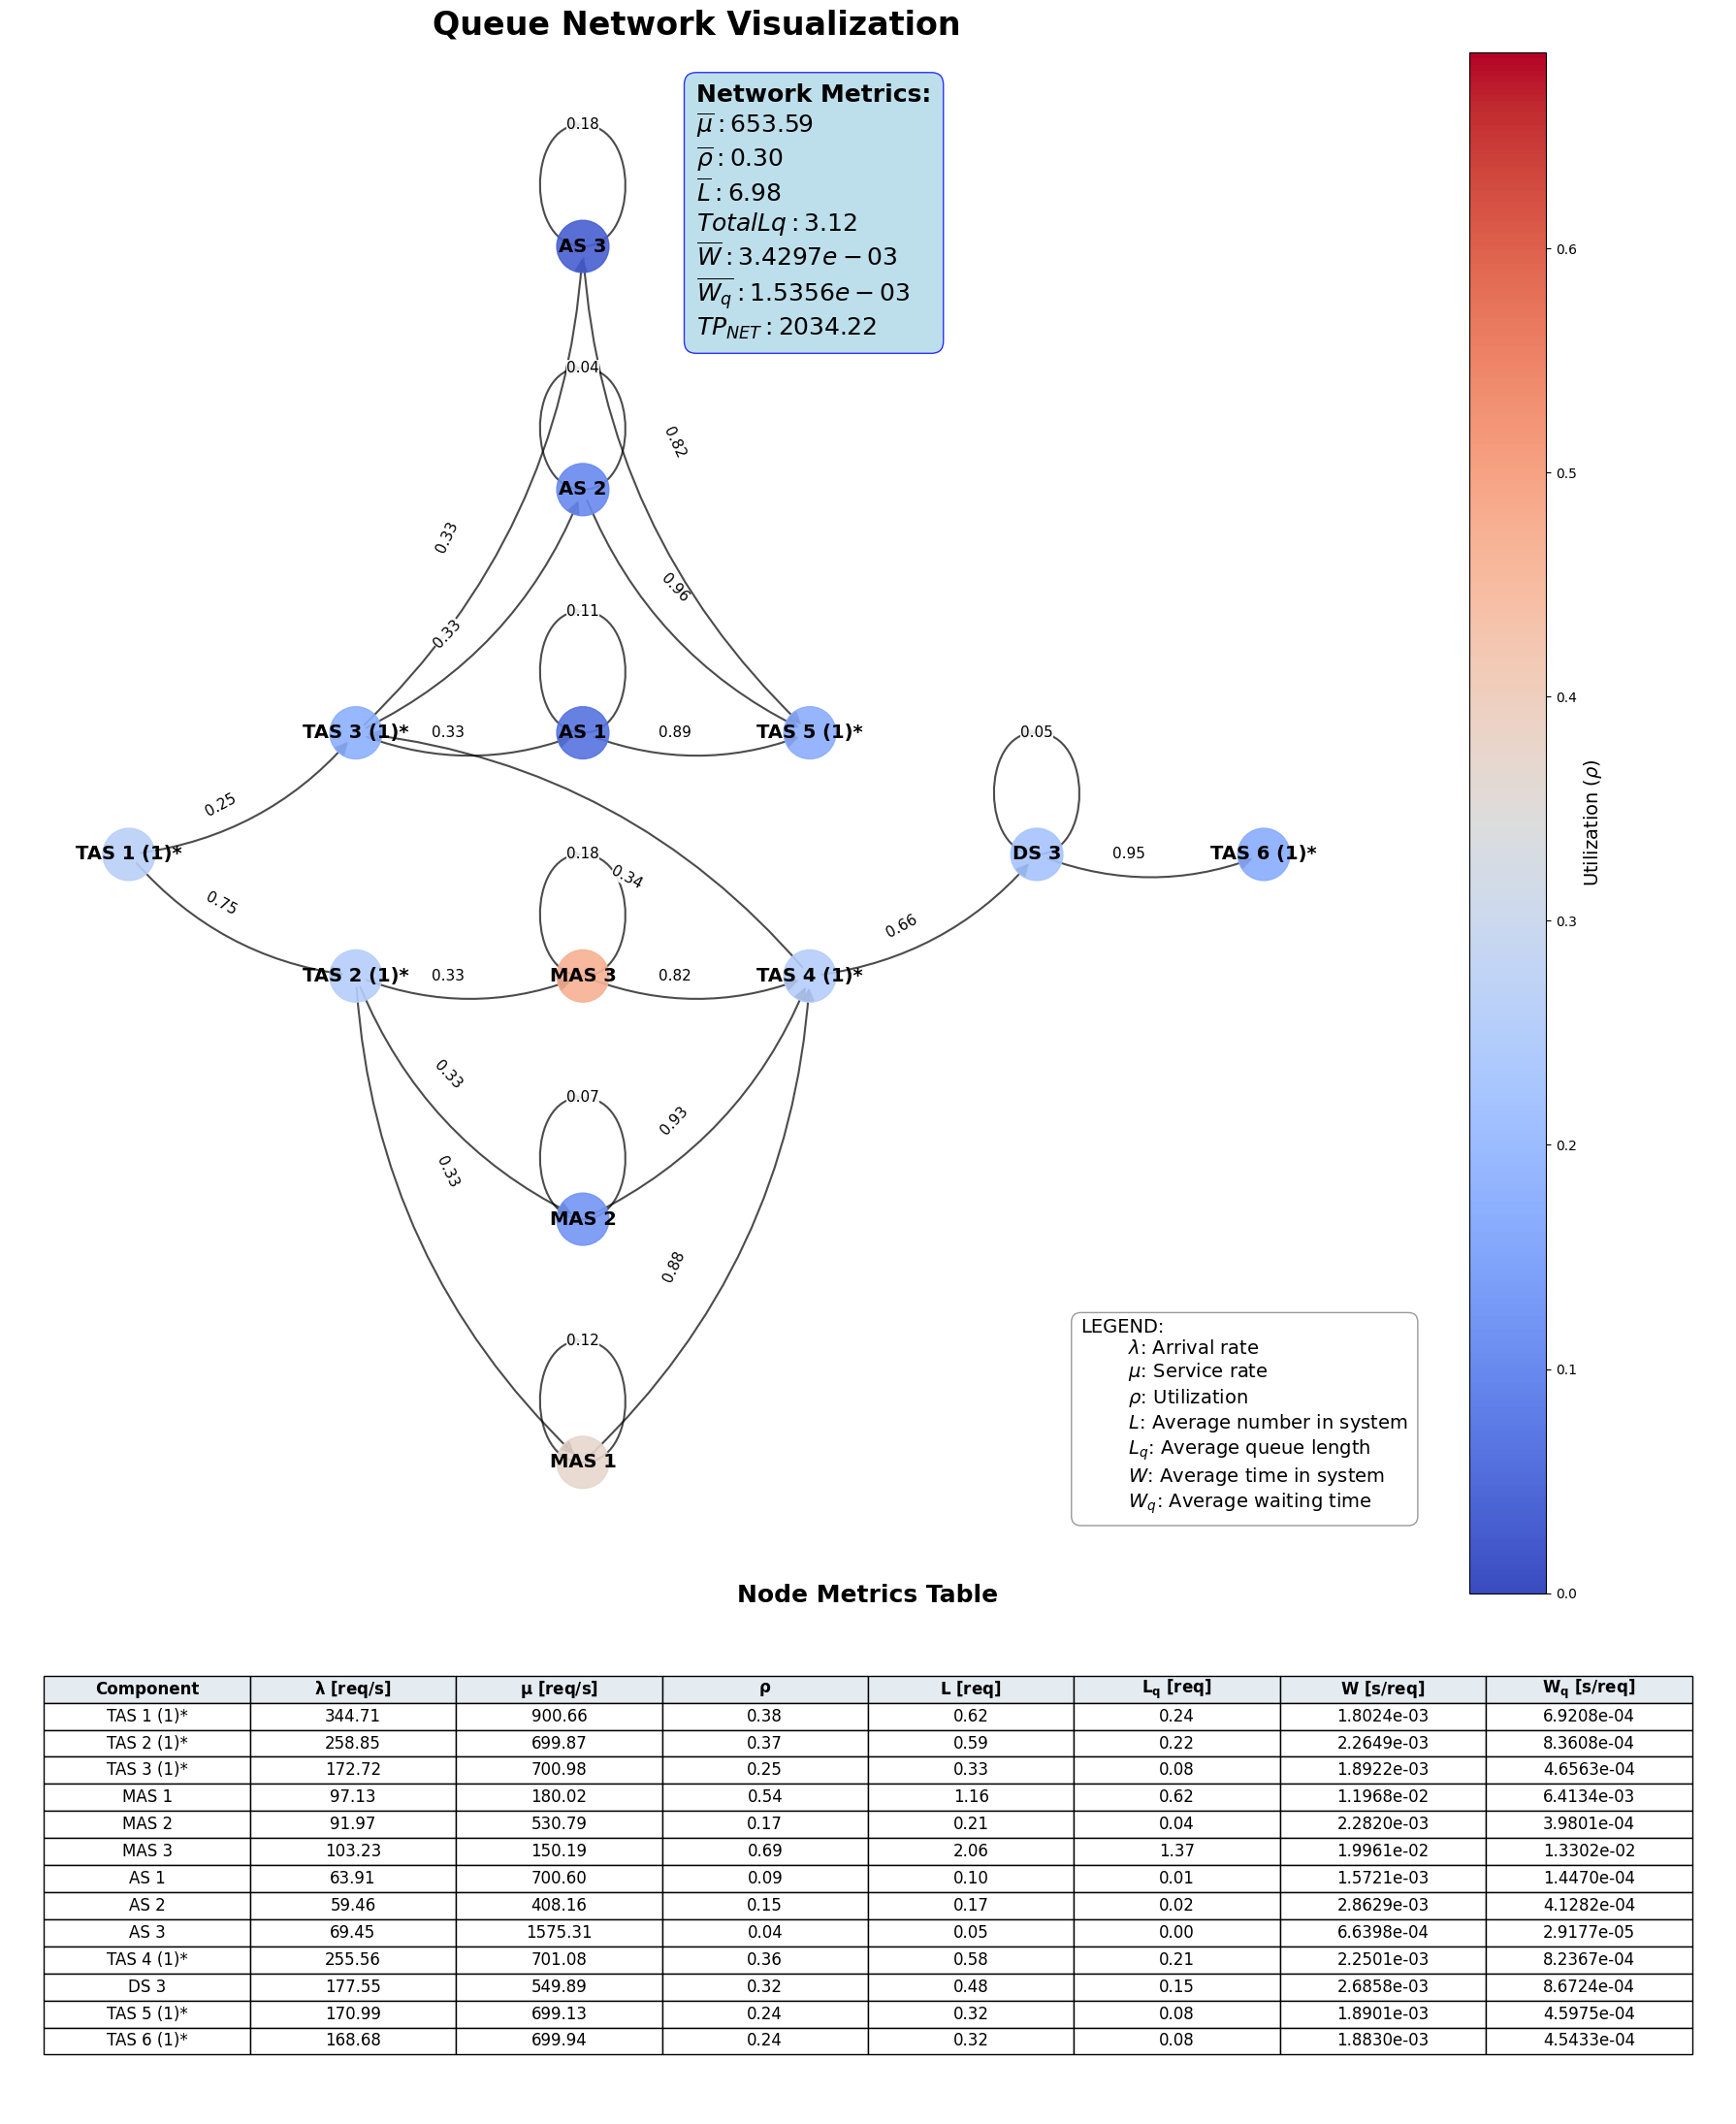

In [17]:
print("--- Plotting Default Stochastic Queue Network ---")
# plotting the queue network with metrics on each node
# data table column names
col_names =[
    "Component",
    r"$\mathbf{\lambda}$ [req/s]",
    r"$\mathbf{\mu}$ [req/s]",
    r"$\mathbf{\rho}$",
    r"$\mathbf{L}$ [req]",
    r"$\mathbf{L_q}$ [req]",
    r"$\mathbf{W}$ [s/req]",
    r"$\mathbf{W_q}$ [s/req]"
]

# P = dflt_stochastics_model[-1]

node_names = dflt_qn_cfg["name"].values.tolist()
print(f"Datatable column names: {col_names}")
print(f"Node names: {node_names}")  

# selecting images folder
file_path = os.path.join(PATH,
                         data_folder,
                         results_folder,
                         cs_folder,
                         img_folder)
print(f"Data path: {file_path}")

# Plot the queue network
plot_queue_network(dflt_stochastics_model[-1],
                   dflt_simul_net_metrics,
                   dflt_simul_nd_metrics,
                   node_names,
                   col_names,
                   file_path,
                   "dflt_stochastic_qn_diagram.png")

##### **Optimized Configuration**

In [18]:
# setting case study configuration folder
file_path = os.path.join(PATH, data_folder, config_folder, cs_folder)
print(f"Configuration file path: {file_path}")

Configuration file path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\config\cs1


In [19]:
# Load configuration with optimal queue models
print("--- Load configuration with optimal queue models ---")
opti_qn_cfg = load(file_path, "optimal_qn_model.csv")
print("Queue Network Configuration:")
# print(opti_qn_cfg)
opti_qn_cfg.head()

--- Load configuration with optimal queue models ---
Loading configuration from: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\config\cs1\optimal_qn_model.csv
Queue Network Configuration:


,node,name,type,mu,c,K,lambda_z,L_z,P_routing
0,1,TAS 1 (1)*,M/M/s/K,900,1,10,345,0,"[0.00,0.75,0.25,0.00,0.00,0.00,0.00,0.00,0.00,..."
1,2,TAS 2 (1)*+,M/M/s/K,700,1,10,0,0,"[0.00,0.00,0.00,0.20,0.40,0.40,0.00,0.00,0.00,..."
2,3,TAS 3 (1)*+,M/M/s/K,700,1,10,0,0,"[0.00,0.00,0.00,0.00,0.00,0.00,0.40,0.40,0.20,..."
3,4,MAS 1,M/M/s/K,180,1,10,0,0,"[0.00,0.00,0.00,0.12,0.00,0.00,0.00,0.00,0.00,..."
4,5,MAS 2,M/M/s/K,530,1,10,0,0,"[0.00,0.00,0.00,0.00,0.07,0.00,0.00,0.00,0.00,..."


In [20]:
print("--- Configuring optimal stochastic queue model ---")
opti_stochastics_model = config_stochastics_model(opti_qn_cfg, verbose=True)

--- Configuring optimal stochastic queue model ---


In [21]:
print("--- Executing optimal stochastic network simulation ---")
opti_simul_nd_metrics = simulate_network(*opti_stochastics_model,
                                         n_exp=n_exp,
                                         warm_exp=n_warmup,
                                         reps=n_reps,
                                         verbose=True)

--- Executing optimal stochastic network simulation ---
--- Running Replication 1/3 ---
--- Running Replication 2/3 ---
--- Running Replication 3/3 ---

=== Summary Statistics Across Replications ===
(13, 21)


In [22]:
print("--- Renaming optimal simulation network metrics ---")
src_df_cols = opti_simul_nd_metrics.columns.tolist()
exp = r"_mean$"
mean_cols = [col for col in src_df_cols if re.search(exp, col)]
print(f"Mean column names: {mean_cols}")

tgt_df_cols = [col.replace("_mean", "") for col in mean_cols]
print(f"Target column names: {tgt_df_cols}")

opti_simul_nd_metrics_mean = pd.DataFrame(opti_simul_nd_metrics[mean_cols])
# rename colums
rename_dict = dict(zip(mean_cols, tgt_df_cols))
print(f"Rename dictionary: {rename_dict}")
opti_simul_nd_metrics.rename(columns=rename_dict, inplace=True)

--- Renaming optimal simulation network metrics ---
Mean column names: ['lambda_mean', 'mu_mean', 'rho_mean', 'L_mean', 'Lq_mean', 'W_mean', 'Wq_mean', 'Jobs_Served_mean', 'Jobs_Blocked_mean', 'Blocking_Prob_mean']
Target column names: ['lambda', 'mu', 'rho', 'L', 'Lq', 'W', 'Wq', 'Jobs_Served', 'Jobs_Blocked', 'Blocking_Prob']
Rename dictionary: {'lambda_mean': 'lambda', 'mu_mean': 'mu', 'rho_mean': 'rho', 'L_mean': 'L', 'Lq_mean': 'Lq', 'W_mean': 'W', 'Wq_mean': 'Wq', 'Jobs_Served_mean': 'Jobs_Served', 'Jobs_Blocked_mean': 'Jobs_Blocked', 'Blocking_Prob_mean': 'Blocking_Prob'}


In [23]:
# then network metrics
print("--- Calculating optimal simulation network metrics ---")
opti_simul_net_metrics = calculate_net_metrics(opti_simul_nd_metrics)
opti_simul_net_metrics["nodes"] = len(list(opti_simul_nd_metrics["node"]))

--- Calculating optimal simulation network metrics ---


In [24]:
print("--- Save Stochastic Network Simulation (Node Metrics) ---")
# print(opti_simul_nd_metrics)

# save data
# select result folder
file_path = os.path.join(PATH,
                         data_folder,
                         results_folder,
                         cs_folder,
                         data_folder)
print(f"Data path: {file_path}")
save(file_path, "opti_stochastic_node_metrics.csv", opti_simul_nd_metrics)
opti_simul_nd_metrics.head()

--- Save Stochastic Network Simulation (Node Metrics) ---
Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data
Saving data to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data\opti_stochastic_node_metrics.csv


,node,lambda,lambda_std,mu,mu_std,rho,rho_std,L,L_std,Lq,...,W,W_std,Wq,Wq_std,Jobs_Served,Jobs_Served_std,Jobs_Blocked,Jobs_Blocked_std,Blocking_Prob,Blocking_Prob_std
0,0,343.864815,0.729659,899.309911,0.970786,0.382365,0.000568,0.619165,0.002000,0.236800,...,0.001801,0.000003,0.000689,0.000004,309478.333333,656.693485,12.666667,6.110101,0.000041,0.000020
1,1,257.571481,0.808323,699.732412,0.608780,0.368099,0.000835,0.582957,0.003370,0.214858,...,0.002263,0.000006,0.000834,0.000007,231814.333333,727.490435,6.666667,5.033223,0.000029,0.000022
2,2,174.020741,0.391651,699.866331,2.550772,0.248650,0.000928,0.330886,0.001034,0.082236,...,0.001901,0.000002,0.000473,0.000004,156618.666667,352.485934,0.000000,0.000000,0.000000,0.000000
3,3,58.461111,0.372116,180.156688,0.976954,0.324501,0.000902,0.479885,0.005562,0.155385,...,0.008209,0.000047,0.002658,0.000068,52615.000000,334.904464,0.000000,0.000000,0.000000,0.000000
4,4,110.755185,0.362136,530.291687,2.231735,0.208859,0.000988,0.263405,0.001571,0.054546,...,0.002378,0.000012,0.000492,0.000005,99679.666667,325.922281,0.000000,0.000000,0.000000,0.000000


In [25]:
print("--- Save Stochastic Network Simulation (Network-wide Metrics) ---")
# print(opti_simul_net_metrics)
# opti_simul_net_metrics.head()

# save data
# select result folder
file_path = os.path.join(PATH,
                         data_folder,
                         results_folder,
                         cs_folder,
                         data_folder)
print(f"Data path: {file_path}")
save(file_path, "opti_stochastic_net_metrics.csv", opti_simul_net_metrics)
opti_simul_net_metrics.head()

--- Save Stochastic Network Simulation (Network-wide Metrics) ---
Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data
Saving data to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data\opti_stochastic_net_metrics.csv


,avg_mu,avg_rho,L_net,Lq_net,W_net,Wq_net,total_throughput,nodes
0,581.619478,0.282521,6.238577,2.565811,0.003093,0.001272,2016.731481,13


Node names: ['TAS 1 (1)*', 'TAS 2 (1)*+', 'TAS 3 (1)*+', 'MAS 1', 'MAS 2', 'MAS 3->4', 'AS 1', 'AS 2', 'AS 3->4', 'TAS 4 (1)*', 'DS 3->1', 'TAS 5 (1)*', 'TAS 6 (1)*']
Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img
Saving plot to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\opti_stochastic_qn_diagram.png
Plot saved successfully to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\opti_stochastic_qn_diagram.png


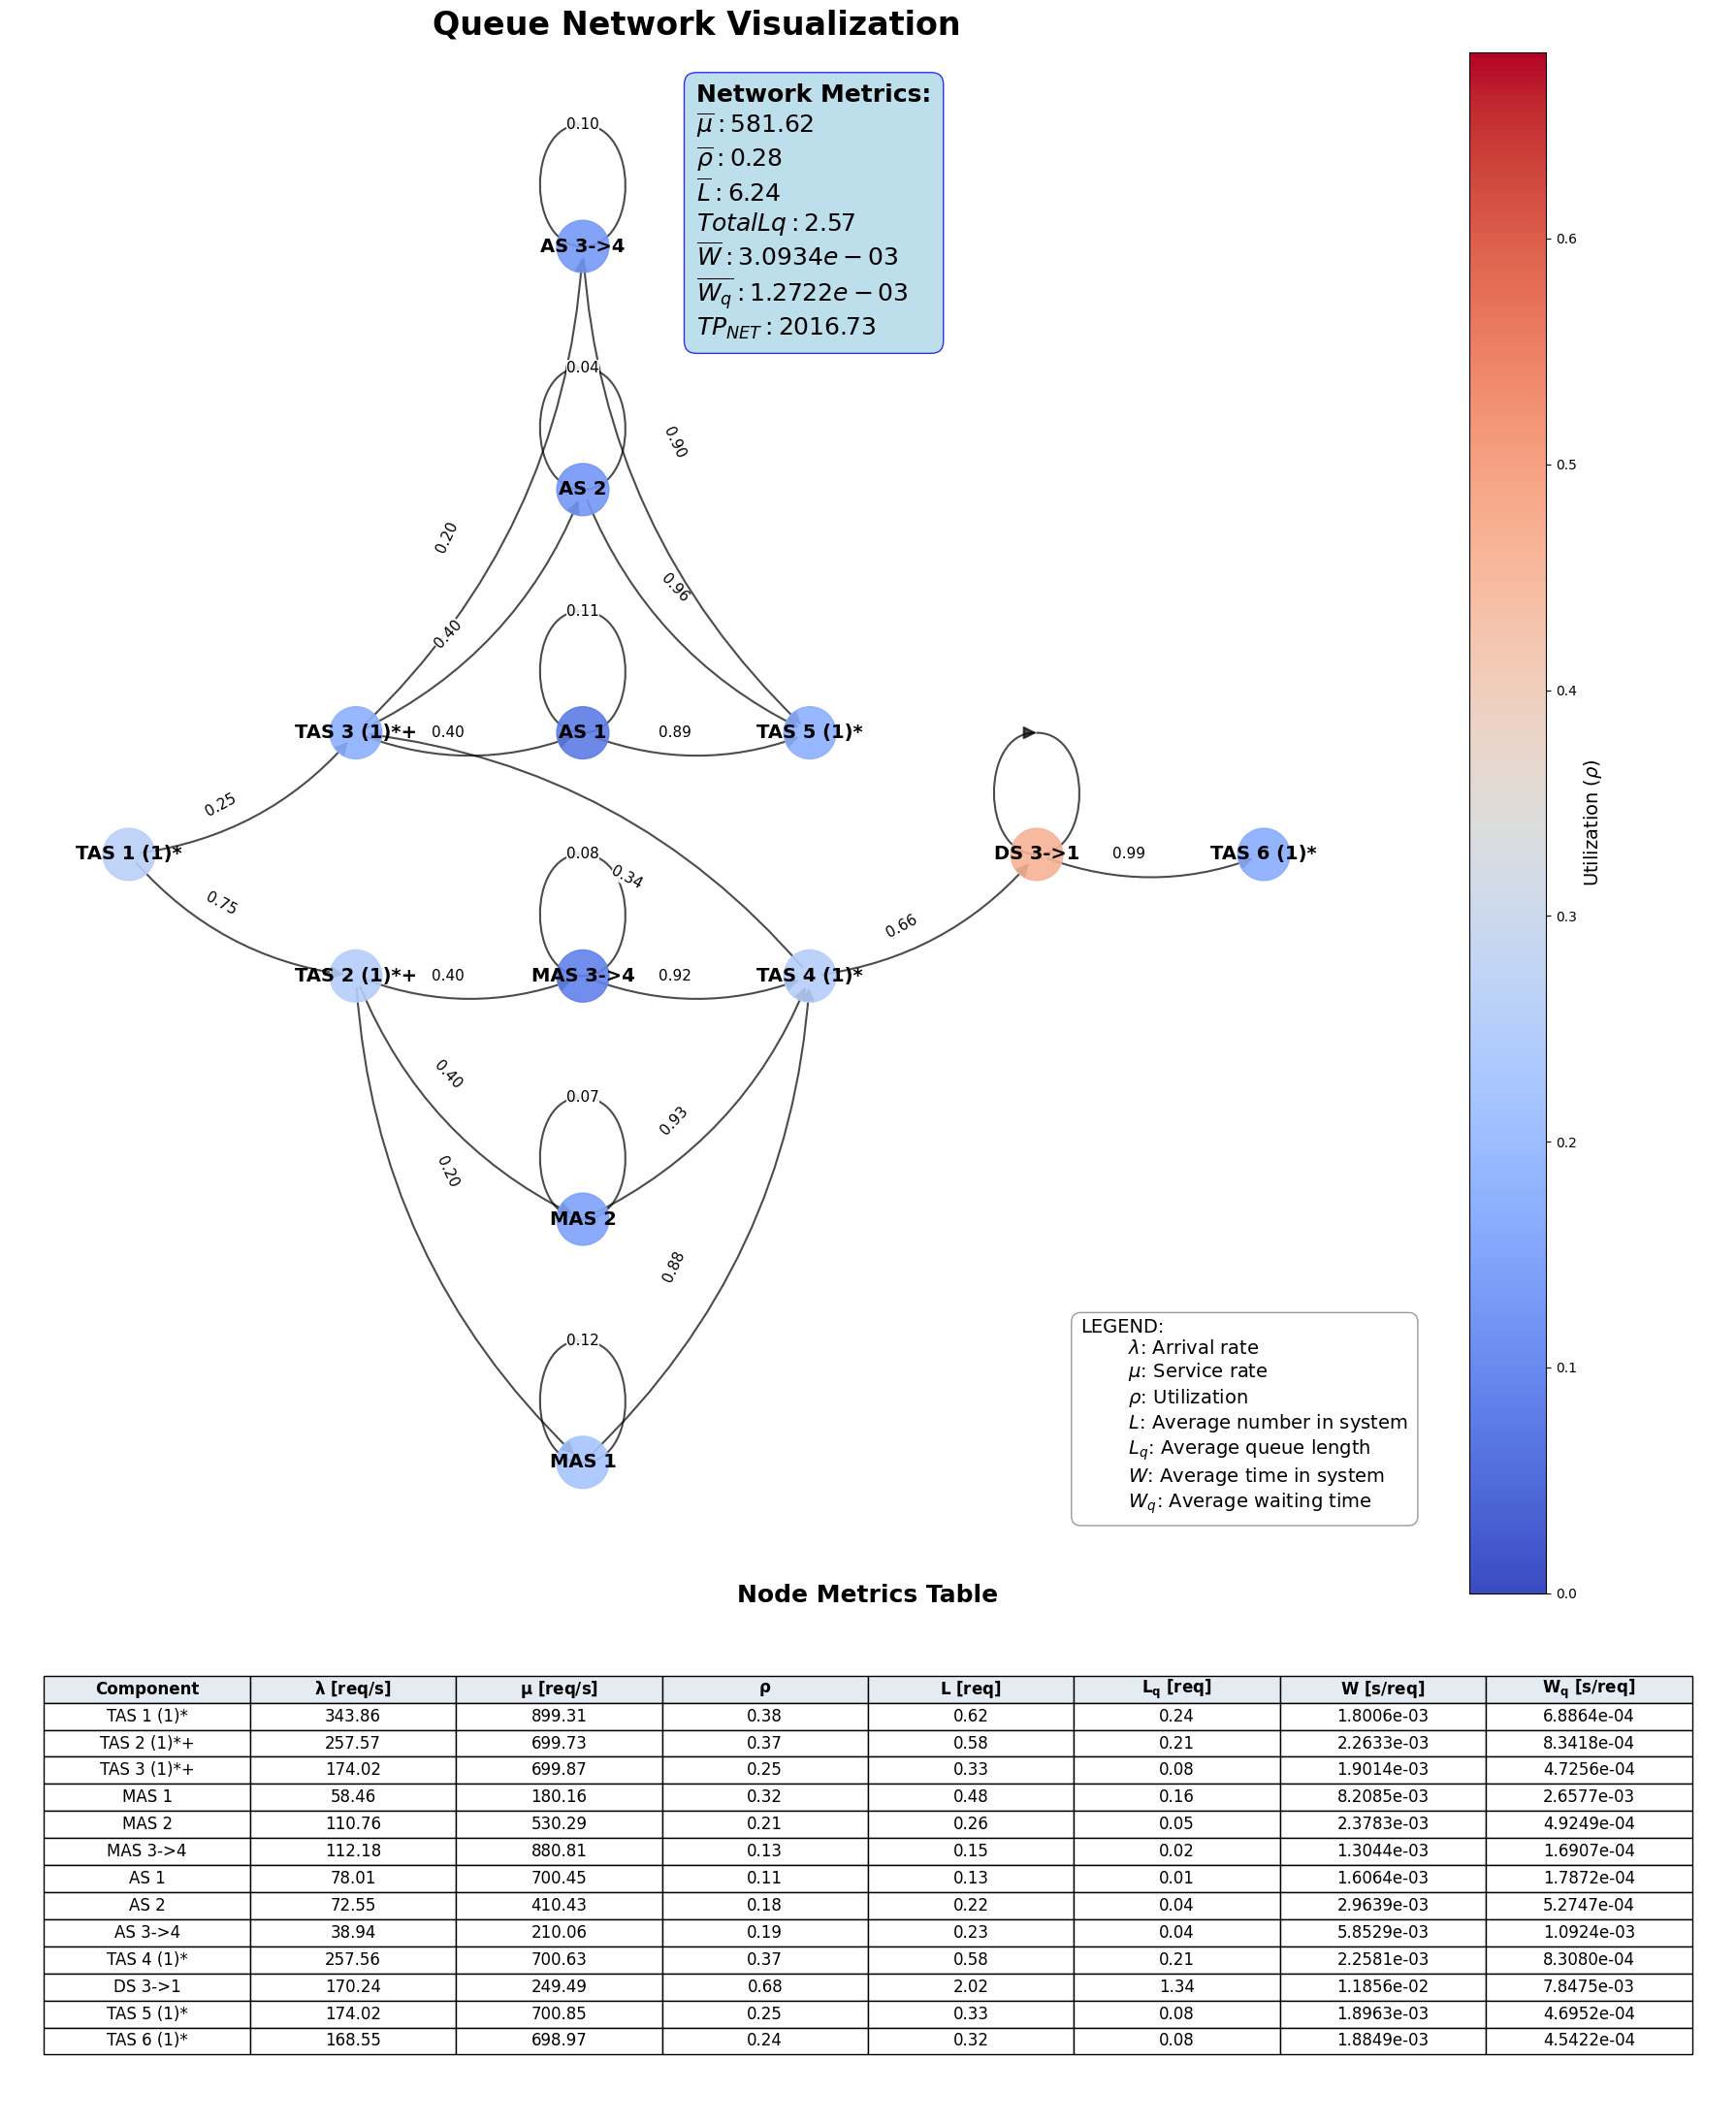

In [26]:
# plotting the queue network with metrics on each node
node_names = opti_qn_cfg["name"].values.tolist()
print(f"Node names: {node_names}")  

# selecting images folder
file_path = os.path.join(PATH,
                         data_folder,
                         results_folder,
                         cs_folder,
                         img_folder)
print(f"Data path: {file_path}")

# Plot the queue network
plot_queue_network(opti_stochastics_model[-1],
                   opti_simul_net_metrics,
                   opti_simul_nd_metrics,
                   node_names,
                   col_names,
                   file_path,
                   "opti_stochastic_qn_diagram.png")

## **Results**

### **Compare Results**

In [27]:
# prep comparison
dsnm = dflt_simul_net_metrics
osnm = opti_simul_net_metrics

In [28]:
print("--- Comparing Stochastic Network Metrics ---")
# comparing network metrics
# diff_simul_net_metrics = opti_simul_net_metrics - dflt_simul_net_metrics
# delta_simul_net_metrics = diff_simul_net_metrics / dflt_simul_net_metrics
delta_simul_net_metrics = (osnm - dsnm) / dsnm.abs()

src_col_names = delta_simul_net_metrics.columns.tolist()

tgt_col_names = [
    "delta_avg_mu",
    "delta_avg_rho",
    "delta_L_net",
    "delta_Lq_net",
    "delta_W_net",
    "delta_Wq_net",
    "delta_throughput",
    "delta_nodes",
]

rename_map = dict(zip(src_col_names, tgt_col_names))
# print(rename_map)

# rename comparison columns
delta_simul_net_metrics.rename(columns=rename_map,
                               inplace=True)
delta_simul_net_metrics.head()

--- Comparing Stochastic Network Metrics ---


,delta_avg_mu,delta_avg_rho,delta_L_net,delta_Lq_net,delta_W_net,delta_Wq_net,delta_throughput,delta_nodes
0,-0.110112,-0.046798,-0.105818,-0.178617,-0.098065,-0.171497,-0.008596,0.0


In [29]:
# preparing data comparison
important_cols = [
    "node",
    "lambda",
    "mu",
    "rho",
    "L",
    "Lq",
    "W",
    "Wq"
]

dsnm = dflt_simul_nd_metrics[important_cols]
osnm = opti_simul_nd_metrics[important_cols]

In [30]:
# comparing node network metrics
print("--- Comparing Stochastic Node/Component Metrics ---")
# extra data columns
extra_cols = [
    "node",
    "name",
    "type",
]

delta_simul_nd_metrics = (osnm - dsnm) / dsnm.abs()

src_col_names = delta_simul_nd_metrics.columns.tolist()

tgt_col_names = [
    "node",
    "delta_lambda",
    "delta_mu",
    "delta_rho",
    "delta_L",
    "delta_Lq",
    "delta_W",
    "delta_Wq",
]

rename_map = dict(zip(src_col_names, tgt_col_names))

# rename comparison columns
delta_simul_nd_metrics.rename(columns=rename_map,
                              inplace=True)

# adding node ID data
for col in extra_cols:
    if col in opti_qn_cfg.columns:
        delta_simul_nd_metrics[col] = opti_qn_cfg[col].values

delta_simul_nd_metrics.head()

--- Comparing Stochastic Node/Component Metrics ---


,node,delta_lambda,delta_mu,delta_rho,delta_L,delta_Lq,delta_W,delta_Wq,name,type
0,1,-0.002465,-0.001501,-0.000967,-0.003446,-0.007420,-0.000989,-0.004975,TAS 1 (1)*,M/M/s/K
1,2,-0.004942,-0.000201,-0.004746,-0.005658,-0.007219,-0.000703,-0.002265,TAS 2 (1)*+,M/M/s/K
2,3,0.007511,-0.001592,0.009119,0.012416,0.022514,0.004855,0.014881,TAS 3 (1)*+,M/M/s/K
3,4,-0.398133,0.000748,-0.398585,-0.587218,-0.750586,-0.314143,-0.585609,MAS 1,M/M/s/K
4,5,0.204253,-0.000940,0.205395,0.255053,0.490148,0.042185,0.237405,MAS 2,M/M/s/K


### **Saving Results**

In [31]:
# save data
# select result folder
file_path = os.path.join(PATH,
                         data_folder,
                         results_folder,
                         cs_folder,
                         data_folder)
print(f"Data path: {file_path}")
save(file_path,
     "delta_stochastic_node_metrics.csv",
     delta_simul_nd_metrics)

Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data
Saving data to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data\delta_stochastic_node_metrics.csv


In [32]:
# save data
# select result folder
file_path = os.path.join(PATH,
                         data_folder,
                         results_folder,
                         cs_folder,
                         data_folder)
print(f"Data path: {file_path}")
save(file_path,
     "delta_stochastic_net_metrics.csv",
     delta_simul_net_metrics)

Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data
Saving data to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data\delta_stochastic_net_metrics.csv


## **Analysis**

### **Graph Analysis**

In [33]:
# selecting images folder
print("--- Configuring folder path for plot parameters ---")
file_path = os.path.join(PATH,
                         data_folder,
                         results_folder,
                         cs_folder,
                         img_folder)
print(f"Data path: {file_path}")

--- Configuring folder path for plot parameters ---
Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img


In [34]:
print("--- Charting Overall Configuration Comparisons ---")
metrics = dflt_simul_net_metrics.columns.tolist()
labels = [
    "$\\mathbf{\\mu}$ [req/s]",
    "$\\mathbf{\\rho}$ [%]",
    "$\\mathbf{L_{net}}$ [req]",
    "$\\mathbf{L_{q_{net}}}$ [req]",
    "$\\mathbf{W_{net}}$ [s/req]",
    "$\\mathbf{W_{q_{net}}}$ [s/req]",
    "$\\mathbf{Th_{net}}$ [req]",
    "$\\mathbf{n}$ [comp]",
]

for m, l in zip(metrics, labels):
    print(f"{m:18} : {l}")

--- Charting Overall Configuration Comparisons ---
avg_mu             : $\mathbf{\mu}$ [req/s]
avg_rho            : $\mathbf{\rho}$ [%]
L_net              : $\mathbf{L_{net}}$ [req]
Lq_net             : $\mathbf{L_{q_{net}}}$ [req]
W_net              : $\mathbf{W_{net}}$ [s/req]
Wq_net             : $\mathbf{W_{q_{net}}}$ [s/req]
total_throughput   : $\mathbf{Th_{net}}$ [req]
nodes              : $\mathbf{n}$ [comp]


Saving plot to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\net_stochastic_metric_comparison.png
Plot saved successfully to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\net_stochastic_metric_comparison.png


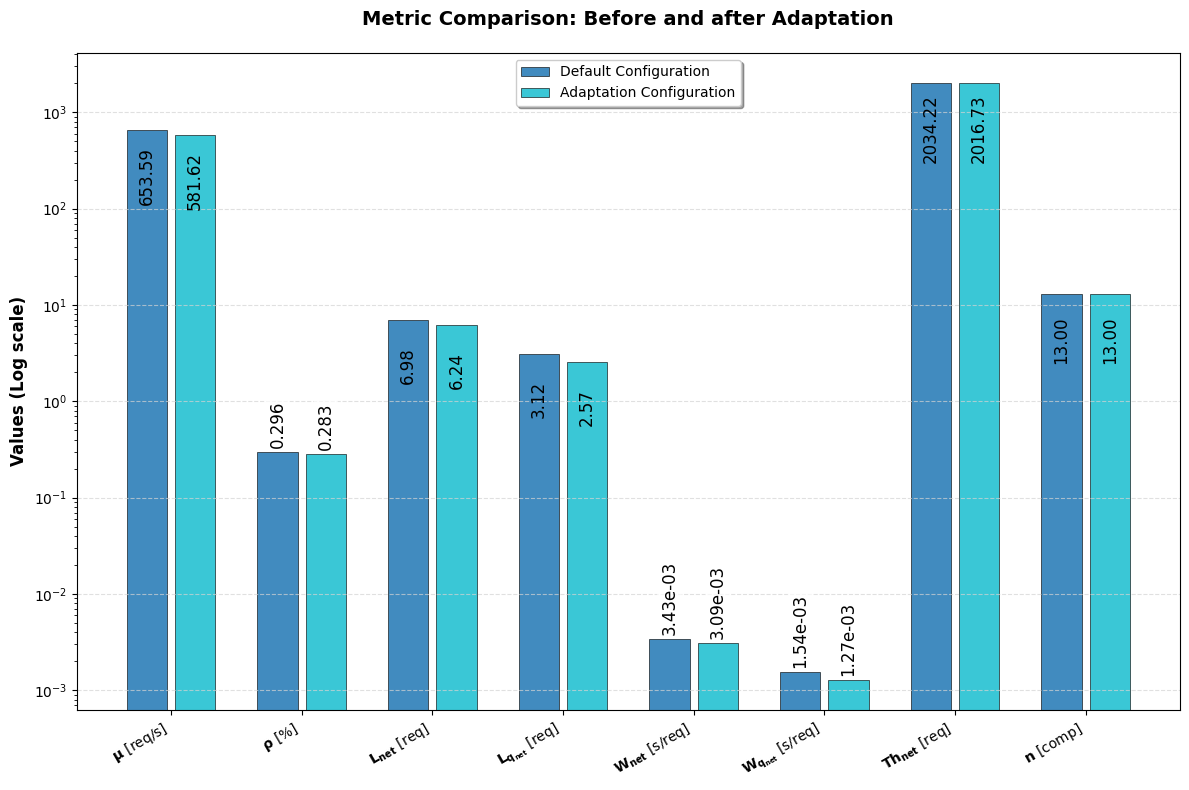

In [35]:
# Plot the metric comparison
plot_net_comparison([dflt_simul_net_metrics, opti_simul_net_metrics],
                    ["Default Configuration", "Adaptation Configuration"],
                    metrics,
                    labels,
                    "Metric Comparison: Before and after Adaptation",
                    file_path,
                    "net_stochastic_metric_comparison.png")

In [36]:
print("--- Charting Overall Configuration differences ---")
metrics = delta_simul_net_metrics.columns.tolist()
labels = [
    "$\\mathbf{\\overline{\\Delta \\mu}}$ [req/s]",
    "$\\mathbf{\\overline{\\Delta \\rho}}$ [n.a.]",
    "$\\mathbf{\\overline{\\Delta L}_{net}}$ [req]",
    "$\\mathbf{\\overline{\\Delta L}_{q_{net}}}$ [req]",
    "$\\mathbf{\\overline{\\Delta W}_{net}}$ [s/req]",
    "$\\mathbf{\\overline{\\Delta W}_{q_{net}}}$ [s/req]",
    "$\\mathbf{\\overline{\\Delta Th}_{net}}$ [req]",
    "$\\mathbf{\\overline{\\Delta n}}$ [comp]",
]

for m, l in zip(metrics, labels):
    print(f"{m:18} : {l}")

--- Charting Overall Configuration differences ---
delta_avg_mu       : $\mathbf{\overline{\Delta \mu}}$ [req/s]
delta_avg_rho      : $\mathbf{\overline{\Delta \rho}}$ [n.a.]
delta_L_net        : $\mathbf{\overline{\Delta L}_{net}}$ [req]
delta_Lq_net       : $\mathbf{\overline{\Delta L}_{q_{net}}}$ [req]
delta_W_net        : $\mathbf{\overline{\Delta W}_{net}}$ [s/req]
delta_Wq_net       : $\mathbf{\overline{\Delta W}_{q_{net}}}$ [s/req]
delta_throughput   : $\mathbf{\overline{\Delta Th}_{net}}$ [req]
delta_nodes        : $\mathbf{\overline{\Delta n}}$ [comp]


Saving plot to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\net_stochastic_metric_differences.png
Plot saved successfully to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\net_stochastic_metric_differences.png


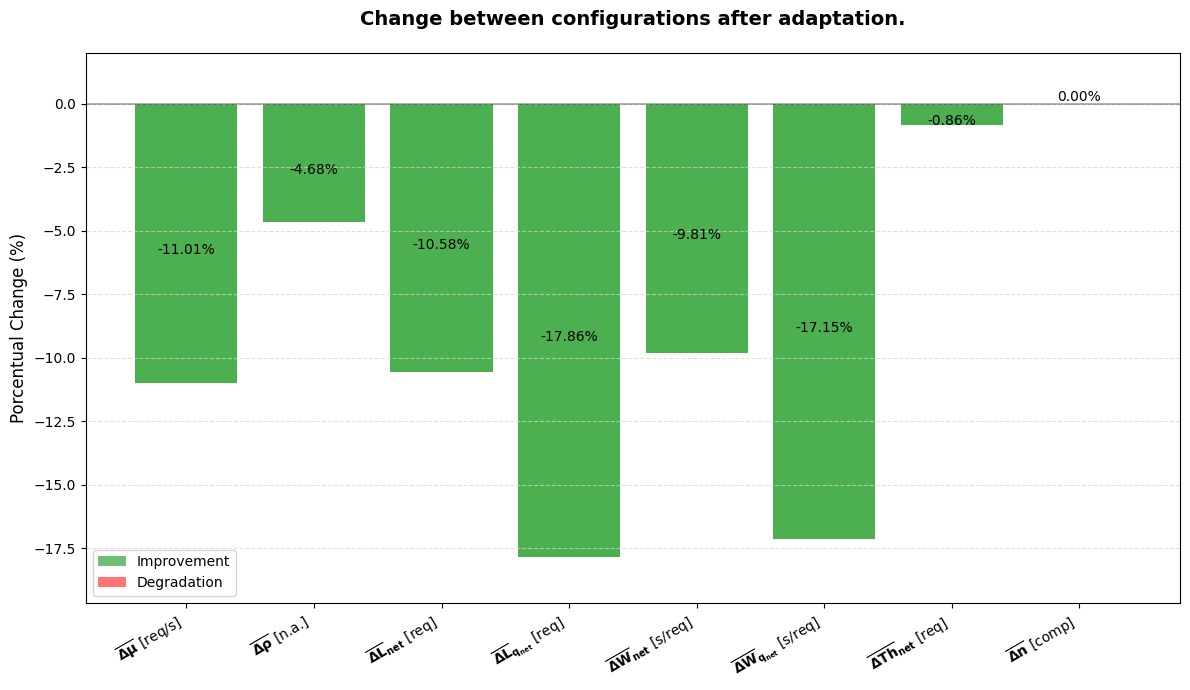

In [37]:
# Plot the metric differences
plot_net_difference(delta_simul_net_metrics,
                    metrics,
                    labels,
                    "Change between configurations after adaptation.",
                    file_path,
                    "net_stochastic_metric_differences.png")

In [38]:
print("--- Charting Component Queue-Network Comparative Heatmap ---")
# Define metrics for the heatmap X-axis
metrics = delta_simul_nd_metrics.select_dtypes(include="number")
metrics = metrics.columns.tolist()
if "node" in metrics:
    metrics.remove("node")

# define the labels for the heatmap X-axis alias
labels = [
    "$\\mathbf{\\Delta\\lambda}$ [req/s]",
    "$\\mathbf{\\Delta \\mu}$ [req/s]",
    "$\\mathbf{\\Delta \\rho}$ [n.a.]",
    "$\\mathbf{\\Delta L_{net}}$ [req]",
    "$\\mathbf{\\Delta L_{q_{net}}}$ [req]",
    "$\\mathbf{\\Delta W_{net}}$ [s/req]",
    "$\\mathbf{\\Delta W_{q_{net}}}$ [s/req]",
]

# define the node names for the heatmap Y-axis
node_names = delta_simul_nd_metrics["name"].values.tolist()
print(f"Node names: {node_names}")

for m, l in zip(metrics, labels):
    print(f"{m:18} : {l}")

--- Charting Component Queue-Network Comparative Heatmap ---
Node names: ['TAS 1 (1)*', 'TAS 2 (1)*+', 'TAS 3 (1)*+', 'MAS 1', 'MAS 2', 'MAS 3->4', 'AS 1', 'AS 2', 'AS 3->4', 'TAS 4 (1)*', 'DS 3->1', 'TAS 5 (1)*', 'TAS 6 (1)*']
delta_lambda       : $\mathbf{\Delta\lambda}$ [req/s]
delta_mu           : $\mathbf{\Delta \mu}$ [req/s]
delta_rho          : $\mathbf{\Delta \rho}$ [n.a.]
delta_L            : $\mathbf{\Delta L_{net}}$ [req]
delta_Lq           : $\mathbf{\Delta L_{q_{net}}}$ [req]
delta_W            : $\mathbf{\Delta W_{net}}$ [s/req]
delta_Wq           : $\mathbf{\Delta W_{q_{net}}}$ [s/req]


In [39]:
print("--- Preparing data for heatmaps ---")
dflt_simul_nd_metrics["name"] = node_names
opti_simul_nd_metrics["name"] = node_names
print(dflt_simul_nd_metrics.columns.tolist())
print(opti_simul_nd_metrics.columns.tolist())

--- Preparing data for heatmaps ---
['node', 'lambda', 'lambda_std', 'mu', 'mu_std', 'rho', 'rho_std', 'L', 'L_std', 'Lq', 'Lq_std', 'W', 'W_std', 'Wq', 'Wq_std', 'Jobs_Served', 'Jobs_Served_std', 'Jobs_Blocked', 'Jobs_Blocked_std', 'Blocking_Prob', 'Blocking_Prob_std', 'name']
['node', 'lambda', 'lambda_std', 'mu', 'mu_std', 'rho', 'rho_std', 'L', 'L_std', 'Lq', 'Lq_std', 'W', 'W_std', 'Wq', 'Wq_std', 'Jobs_Served', 'Jobs_Served_std', 'Jobs_Blocked', 'Jobs_Blocked_std', 'Blocking_Prob', 'Blocking_Prob_std', 'name']


In [40]:
print("--- Charting Component Queue-Network Configuration Heatmap ---")
metrics = dflt_simul_nd_metrics.select_dtypes(include="number")
metrics = metrics.columns.tolist()
if "node" in metrics:
    metrics.remove("node")

labels = [
    # "$\\mathbf{n}$ [comp]",
    "$\\mathbf{\\lambda}$ [req/s]",
    "$\\mathbf{\\mu}$ [req/s]",
    "$\\mathbf{\\rho}$ [%]",
    "$\\mathbf{L}$ [req]",
    "$\\mathbf{L_{q}}$ [req]",
    "$\\mathbf{W}$ [s/req]",
    "$\\mathbf{W_{q}}$ [s/req]",
]

# define the node names for the heatmap Y-axis
node_names = delta_simul_nd_metrics["name"].values.tolist()
print(f"Node names: {node_names}")

for m, l in zip(metrics, labels):
    print(f"{m:18} : {l}")

--- Charting Component Queue-Network Configuration Heatmap ---
Node names: ['TAS 1 (1)*', 'TAS 2 (1)*+', 'TAS 3 (1)*+', 'MAS 1', 'MAS 2', 'MAS 3->4', 'AS 1', 'AS 2', 'AS 3->4', 'TAS 4 (1)*', 'DS 3->1', 'TAS 5 (1)*', 'TAS 6 (1)*']
lambda             : $\mathbf{\lambda}$ [req/s]
lambda_std         : $\mathbf{\mu}$ [req/s]
mu                 : $\mathbf{\rho}$ [%]
mu_std             : $\mathbf{L}$ [req]
rho                : $\mathbf{L_{q}}$ [req]
rho_std            : $\mathbf{W}$ [s/req]
L                  : $\mathbf{W_{q}}$ [s/req]


In [41]:
# removing numeric metrics that Im not interested in
not_interesting = [
    "node",
    "type",
    "L_littles",
    "Lq_littles",
    "Jobs_Served",
    "Jobs_Blocked",
    "Blocking_Prob"
]
print(metrics)
# removing uninteresting columns
metrics = [m for m in metrics if m not in not_interesting]
# removing anything ending in _std
metrics = [m for m in metrics if not m.endswith("_std")]
print(metrics)

['lambda', 'lambda_std', 'mu', 'mu_std', 'rho', 'rho_std', 'L', 'L_std', 'Lq', 'Lq_std', 'W', 'W_std', 'Wq', 'Wq_std', 'Jobs_Served', 'Jobs_Served_std', 'Jobs_Blocked', 'Jobs_Blocked_std', 'Blocking_Prob', 'Blocking_Prob_std']
['lambda', 'mu', 'rho', 'L', 'Lq', 'W', 'Wq']


In [42]:
if "name" not in metrics:
    metrics.append("name")
print(metrics)
print(labels)
print(len(metrics), len(labels))

dsnm = dflt_simul_nd_metrics[metrics]
osnm = opti_simul_nd_metrics[metrics]
# quitar las columnas 'L_littles', 'Lq_littles', 'Jobs_Served', 'Jobs_Blocked', 'Blocking_Prob'

['lambda', 'mu', 'rho', 'L', 'Lq', 'W', 'Wq', 'name']
['$\\mathbf{\\lambda}$ [req/s]', '$\\mathbf{\\mu}$ [req/s]', '$\\mathbf{\\rho}$ [%]', '$\\mathbf{L}$ [req]', '$\\mathbf{L_{q}}$ [req]', '$\\mathbf{W}$ [s/req]', '$\\mathbf{W_{q}}$ [s/req]']
8 7


In [43]:
if "name" in metrics:
    metrics.remove("name")
print(metrics)
print(labels)
print(len(metrics), len(labels))

['lambda', 'mu', 'rho', 'L', 'Lq', 'W', 'Wq']
['$\\mathbf{\\lambda}$ [req/s]', '$\\mathbf{\\mu}$ [req/s]', '$\\mathbf{\\rho}$ [%]', '$\\mathbf{L}$ [req]', '$\\mathbf{L_{q}}$ [req]', '$\\mathbf{W}$ [s/req]', '$\\mathbf{W_{q}}$ [s/req]']
7 7


Saving plot to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\nodes_stochastic_metric_heatmap.png
Plot saved successfully to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\nodes_stochastic_metric_heatmap.png


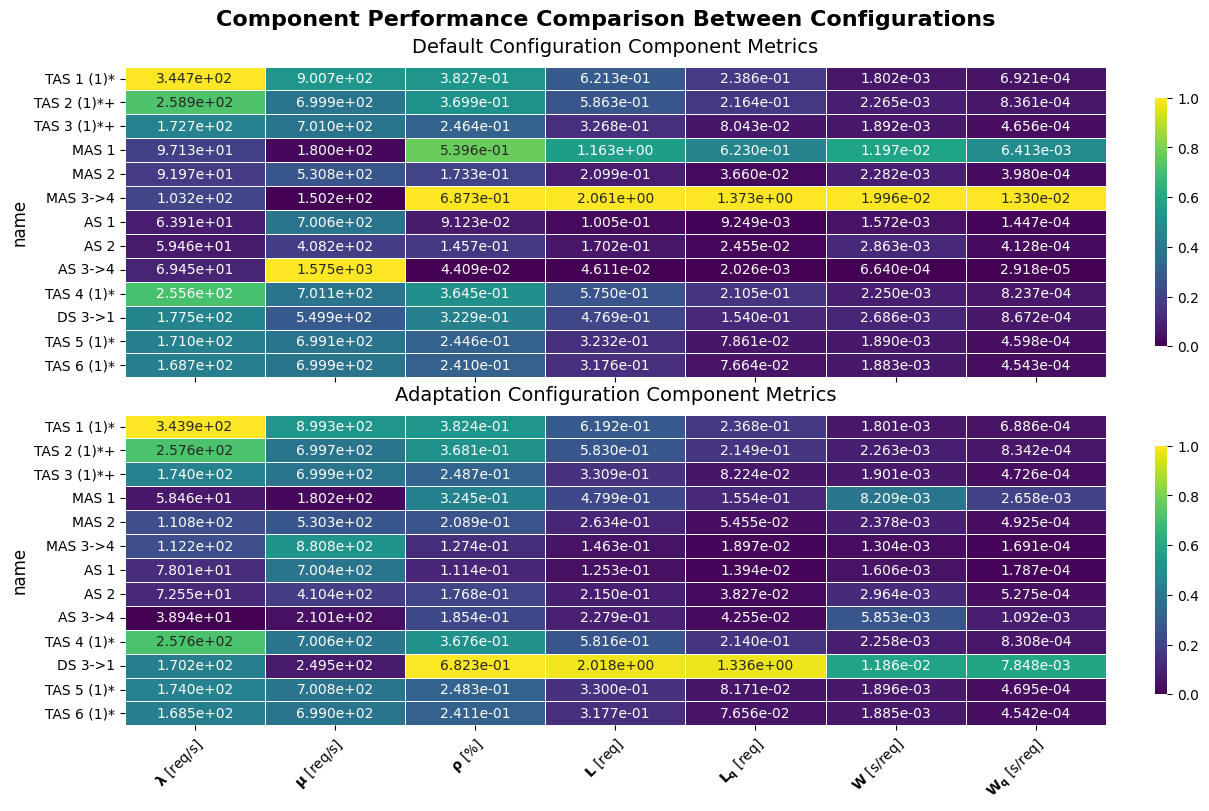

In [44]:
plot_nodes_heatmap([dsnm, osnm],
                   ["Default Configuration", "Adaptation Configuration"],
                   node_names,
                   metrics,
                   labels,
                   "Component Performance Comparison Between Configurations",
                   "name",
                   file_path,
                   "nodes_stochastic_metric_heatmap.png")

In [45]:
print("--- Charting Component Queue-Network Differential Heatmap ---")
# Define metrics for the heatmap X-axis
metrics = delta_simul_nd_metrics.select_dtypes(include="number")
metrics = metrics.columns.tolist()
if "node" in metrics:
    metrics.remove("node")

# define the labels for the heatmap X-axis alias
labels = [
    "$\\mathbf{\\Delta\\lambda}$ [%]",
    "$\\mathbf{\\Delta \\mu}$ [%]",
    "$\\mathbf{\\Delta \\rho}$ [%]",
    "$\\mathbf{\\Delta L_{net}}$ [%]",
    "$\\mathbf{\\Delta L_{q_{net}}}$ [%]",
    "$\\mathbf{\\Delta W_{net}}$ [%]",
    "$\\mathbf{\\Delta W_{q_{net}}}$ [%]",
]

# define the node names for the heatmap Y-axis
node_names = delta_simul_nd_metrics["name"].values.tolist()
print(f"Node names: {node_names}")

for m, l in zip(metrics, labels):
    print(f"{m:18} : {l}")

--- Charting Component Queue-Network Differential Heatmap ---
Node names: ['TAS 1 (1)*', 'TAS 2 (1)*+', 'TAS 3 (1)*+', 'MAS 1', 'MAS 2', 'MAS 3->4', 'AS 1', 'AS 2', 'AS 3->4', 'TAS 4 (1)*', 'DS 3->1', 'TAS 5 (1)*', 'TAS 6 (1)*']
delta_lambda       : $\mathbf{\Delta\lambda}$ [%]
delta_mu           : $\mathbf{\Delta \mu}$ [%]
delta_rho          : $\mathbf{\Delta \rho}$ [%]
delta_L            : $\mathbf{\Delta L_{net}}$ [%]
delta_Lq           : $\mathbf{\Delta L_{q_{net}}}$ [%]
delta_W            : $\mathbf{\Delta W_{net}}$ [%]
delta_Wq           : $\mathbf{\Delta W_{q_{net}}}$ [%]


Found 13 nodes: ['TAS 1 (1)*' 'TAS 2 (1)*+' 'TAS 3 (1)*+' 'MAS 1' 'MAS 2' 'MAS 3->4'
 'AS 1' 'AS 2' 'AS 3->4' 'TAS 4 (1)*' 'DS 3->1' 'TAS 5 (1)*' 'TAS 6 (1)*']
Heatmap data shape: (13, 7)
Saving plot to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\nodes_stochastic_metric_diffmap.png
Plot saved successfully to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\nodes_stochastic_metric_diffmap.png


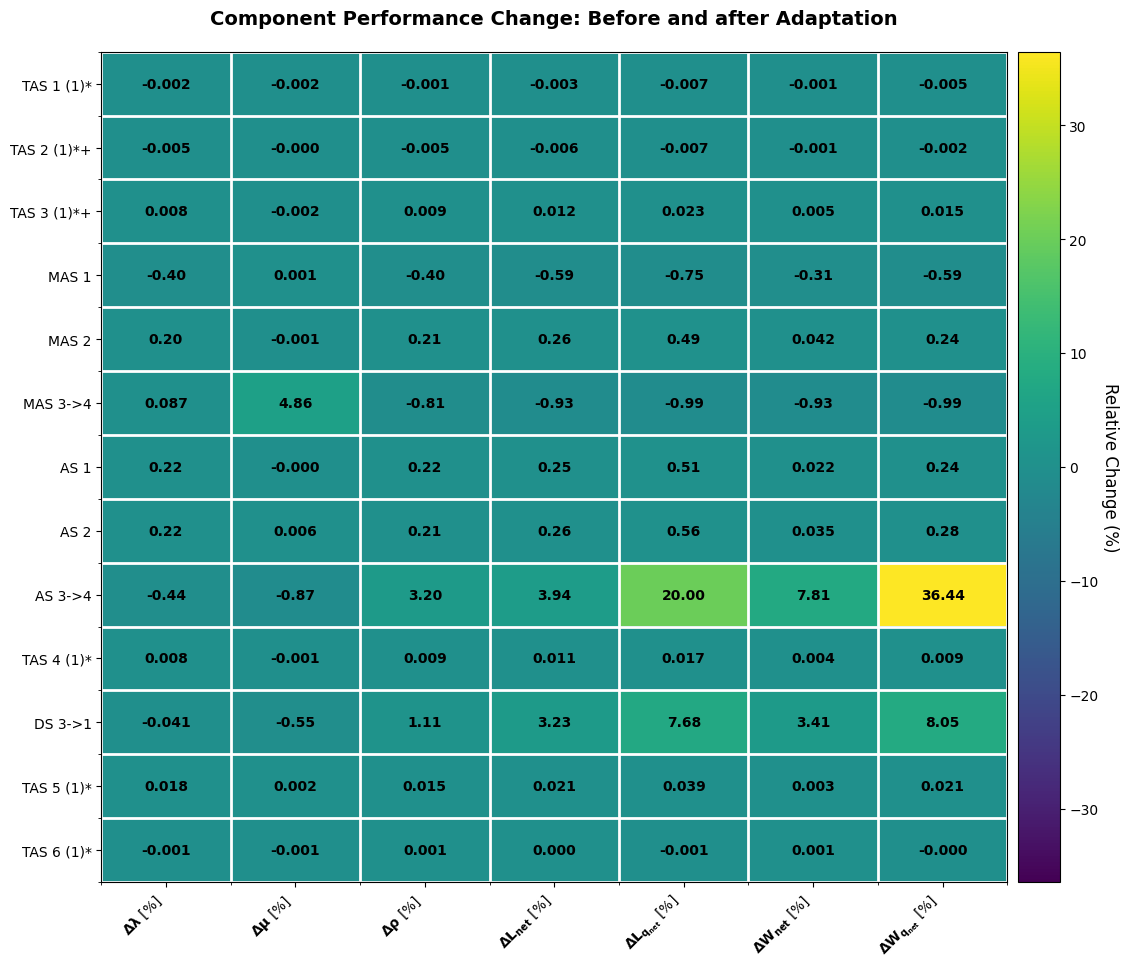

In [46]:
plot_nodes_diffmap(delta_simul_nd_metrics,
                   node_names,
                   metrics,
                   labels,
                   "Component Performance Change: Before and after Adaptation",
                   "name",
                   file_path,
                   "nodes_stochastic_metric_diffmap.png")

## **Conclusion**

## **Future Work**

## **References & Sources**
<!-- TODO fix the references, links and details -->
1. [Queueing Theory](https://en.wikipedia.org/wiki/Queueing_theory)
2. [Dimensional Analysis](https://en.wikipedia.org/wiki/Dimensional_analysis)
3. [Simulation in Healthcare](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6466220/)

---

# **HASTA AKI!!!**